In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Cleaning and preprocessing
df = pd.read_csv('heart_disease.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (4238, 16)


,Gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,Heart_ stroke
0,Male,39,postgraduate,0,0.0,0.0,no,0,0,195.0,106.0,70.0,26.97,80.0,77.0,No
1,Female,46,primaryschool,0,0.0,0.0,no,0,0,250.0,121.0,81.0,28.73,95.0,76.0,No
2,Male,48,uneducated,1,20.0,0.0,no,0,0,245.0,127.5,80.0,25.34,75.0,70.0,No
3,Female,61,graduate,1,30.0,0.0,no,1,0,225.0,150.0,95.0,28.58,65.0,103.0,yes
4,Female,46,graduate,1,23.0,0.0,no,0,0,285.0,130.0,84.0,23.10,85.0,85.0,No


In [ ]:
# strip leading/trailing spaces, lowercase everything
df = df.rename(columns = {'Heart_ stroke': 'heart_stroke'})
df.columns = df.columns.str.strip().str.lower()
print(df.columns.tolist())

['gender', 'age', 'education', 'currentsmoker', 'cigsperday', 'bpmeds', 'prevalentstroke', 'prevalenthyp', 'diabetes', 'totchol', 'sysbp', 'diabp', 'bmi', 'heartrate', 'glucose', 'heart_stroke']


In [ ]:
df = pd.read_csv('heart_disease.csv')
df = df.rename(columns = {'Heart_ stroke': 'heart_stroke'})
df.columns = df.columns.str.strip().str.lower()

# Binary encoding
# Target
df['heart_stroke'] = (df['heart_stroke']
    .astype(str).str.strip().str.lower()
    .map({'yes': 1, 'no': 0}))

# Gender
df['gender'] = (df['gender']
    .astype(str).str.strip().str.lower()
    .map({'male': 1, 'female': 0}))

# prevalentStroke
df['prevalentstroke'] = (df['prevalentstroke']
    .astype(str).str.strip().str.lower()
    .map({'yes': 1, 'no': 0}))

# Education: ordinal encoding
edu_order = {'uneducated': 0, 'primaryschool': 1,
             'graduate': 2, 'postgraduate': 3}
df['education'] = (df['education']
    .astype(str).str.strip().str.lower()
    .map(edu_order))


In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
education,105
cigsperday,29
bpmeds,53
totchol,50
bmi,19
heartrate,1
glucose,388


In [ ]:
df['cigsperday'] = df['cigsperday'].fillna(
    df.groupby('currentsmoker')['cigsperday'].transform('median')
)

# bpmeds: mode (0)
df['bpmeds'] = df['bpmeds'].fillna(df['bpmeds'].mode()[0])

# simple median fills
for col in ['totchol', 'bmi', 'heartrate']:
    df[col] = df[col].fillna(df[col].median())

# glucose: stratified by diabetes status
df['glucose'] = df['glucose'].fillna(
    df.groupby('diabetes')['glucose'].transform('median')
)

# education: already encoded, fill NaN with 0 (uneducated = most common)
df['education'] = df['education'].fillna(0)

print("Remaining NaNs:", df.isnull().sum().sum())

Remaining NaNs: 0


In [ ]:
continuous_cols = ['cigsperday', 'totchol', 'sysbp', 'diabp',
                   'bmi', 'heartrate', 'glucose']

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

In [ ]:
# Pulse pressure: clinical indicator of arterial stiffness
df['pulse_pressure'] = df['sysbp'] - df['diabp']

# Heavy smoker flag: > 20 cigs/day (1 pack)
df['heavy_smoker'] = (df['cigsperday'] > 20).astype(int)

# Age group: ordinal bins
df['age_group'] = pd.cut(
    df['age'], bins=[0, 40, 50, 60, 100],
    labels=['<40', '40-50', '50-60', '60+']
).cat.codes  # 0-3

print(f"New features: pulse_pressure, heavy_smoker, age_group")
print(f"Final shape: {df.shape}")

New features: pulse_pressure, heavy_smoker, age_group
Final shape: (4238, 19)


In [ ]:
df['heart_stroke'].value_counts(normalize=True).round(3)


,proportion
heart_stroke,
0,0.848
1,0.152


In [ ]:
df.to_csv('heart_disease_cleaned.csv', index=False)
print("Saved: heart_disease_cleaned.csv")
print(f"Final columns ({len(df.columns)}): {df.columns.tolist()}")

Saved: heart_disease_cleaned.csv
Final columns (19): ['gender', 'age', 'education', 'currentsmoker', 'cigsperday', 'bpmeds', 'prevalentstroke', 'prevalenthyp', 'diabetes', 'totchol', 'sysbp', 'diabp', 'bmi', 'heartrate', 'glucose', 'heart_stroke', 'pulse_pressure', 'heavy_smoker', 'age_group']


## 3. Research & Related Work

Before conducting our analysis, we reviewed the following related papers:

---

**1. Heart Disease Prediction Using Machine Learning**
*(Sashank Yadav, Aman Singh, Veena Jadhav, Dr. Rohini Jadhav)*

This paper tested 7 ML algorithms (Naive Bayes, Decision Tree, Logistic Regression,
KNN, SVM, Gradient Boosting, and Random Forest) on the UCI heart disease dataset.
KNN achieved the highest accuracy at 85.18%. They also deployed their final model
as a Flask web application using a pickle file — which inspired our approach of
saving our final model as a `.pkl` file for our interactive demo.

---

**2. Effective Heart Disease Prediction Using Hybrid Machine Learning Techniques**
*(Mohan, Thirumalai & Srivastava — IEEE)*

This paper proposed a hybrid model combining Random Forest with a Linear Model (HRFLM),
achieving 88.7% accuracy on cardiovascular disease prediction. Their emphasis on
feature selection to improve accuracy directly influenced our feature engineering
decisions, such as creating `pulse_pressure` and `age_group` as new meaningful features.

---

**3. Heart Disease Prediction Using Machine Learning Techniques**
*(Apurv Garg, Bhartendu Sharma & Rijwan Khan — IOP Publishing)*

This paper focused on KNN and Random Forest for classifying heart disease patients,
achieving 86.9% and 82.0% accuracy respectively. Their finding that tree-based
ensemble methods generalize well on medical data supported our decision to include
Random Forest as one of our three models.

---

**Key Takeaway:**
All three papers consistently show that ensemble methods — especially Random Forest —
perform strongly on heart disease prediction tasks. This validated our model selection
strategy and confirmed that the features we engineered (blood pressure, age, smoking
habits) are clinically meaningful predictors.

In [ ]:
# Research and data analysis (EDA)
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Statistical summary:
summary_stats = df.describe()
print("Summary Statistics:\n", summary_stats)

Summary Statistics:
             gender          age    education  currentsmoker   cigsperday  \
count  4238.000000  4238.000000  4238.000000    4238.000000  4238.000000   
mean      0.429212    49.584946     0.954696       0.494101     9.047664   
std       0.495022     8.572160     1.018510       0.500024    11.792882   
min       0.000000    32.000000     0.000000       0.000000     0.000000   
25%       0.000000    42.000000     0.000000       0.000000     0.000000   
50%       0.000000    49.000000     1.000000       0.000000     0.000000   
75%       1.000000    56.000000     2.000000       1.000000    20.000000   
max       1.000000    70.000000     3.000000       1.000000    50.000000   

            bpmeds  prevalentstroke  prevalenthyp     diabetes      totchol  \
count  4238.000000      4238.000000   4238.000000  4238.000000  4238.000000   
mean      0.029259         0.005899      0.310524     0.025720   236.191600   
std       0.168552         0.076587      0.462763     0.1

/tmp/ipykernel_1437/3362624218.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'heart_stroke', data = df, palette = 'viridis')


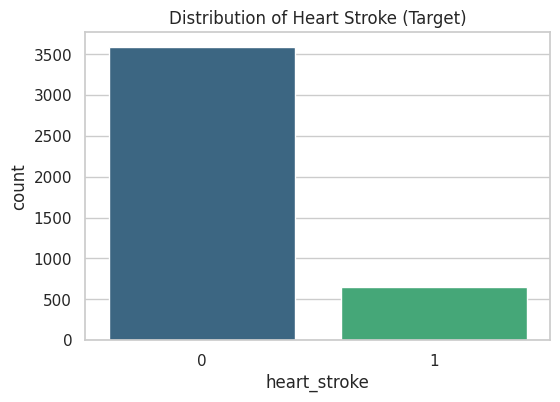

In [ ]:
# Visualizations:
sns.set(style = 'whitegrid')

# 1. Distribution of Heart Stroke (Target)
plt.figure(figsize = (6, 4))
sns.countplot(x = 'heart_stroke', data = df, palette = 'viridis')
plt.title('Distribution of Heart Stroke (Target)')
plt.show()

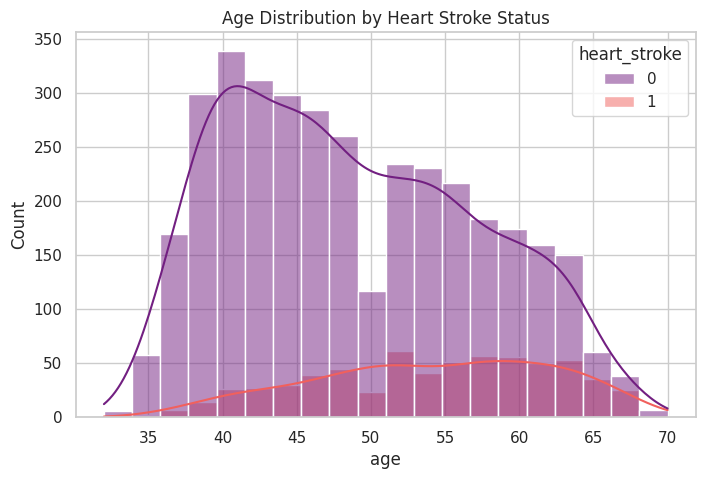

In [ ]:
# 2. Age vs Heart Stroke
plt.figure(figsize = (8, 5))
sns.histplot(data = df, x = 'age', hue = 'heart_stroke', kde = True, bins = 20, palette = 'magma')
plt.title('Age Distribution by Heart Stroke Status')
plt.show()

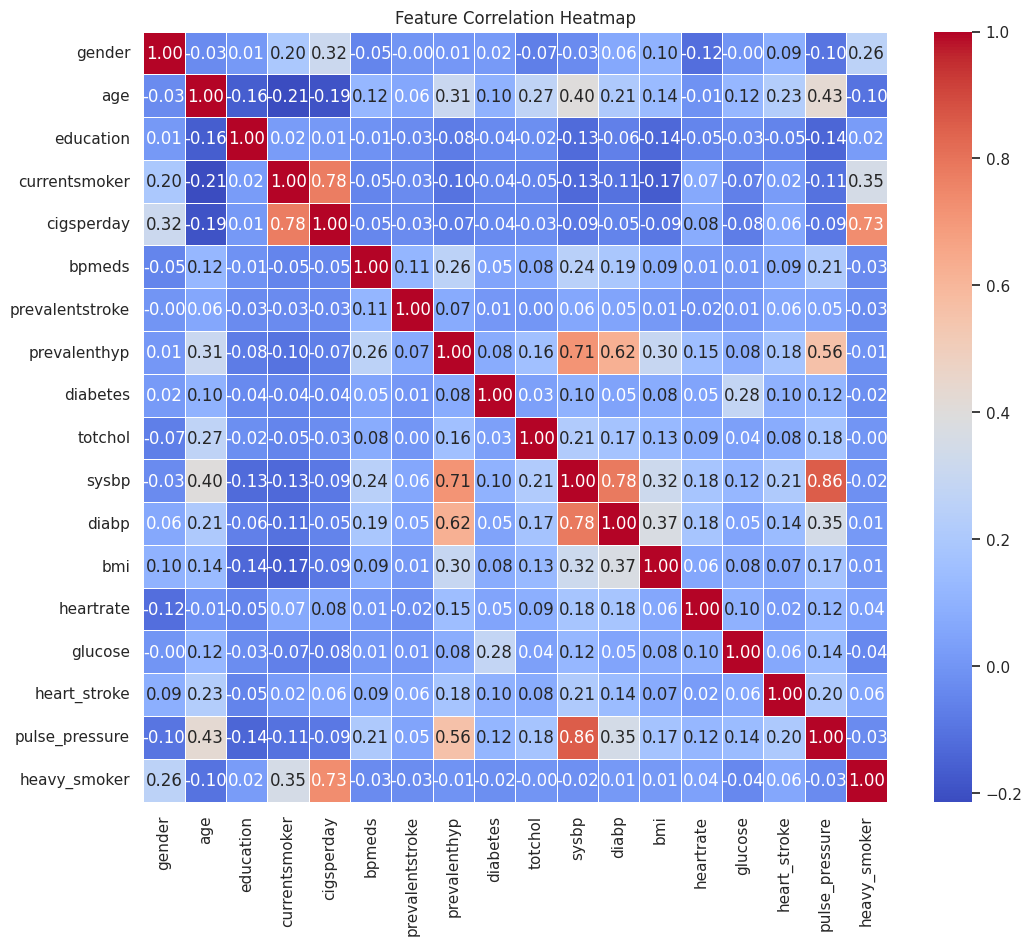

In [ ]:
# 3. Correlation Heatmap
numeric_df = df.select_dtypes(include = ['float64', 'int64'])
plt.figure(figsize = (12, 10))
sns.heatmap(numeric_df.corr(), annot = True, fmt = '.2f', cmap = 'coolwarm', linewidths = 0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

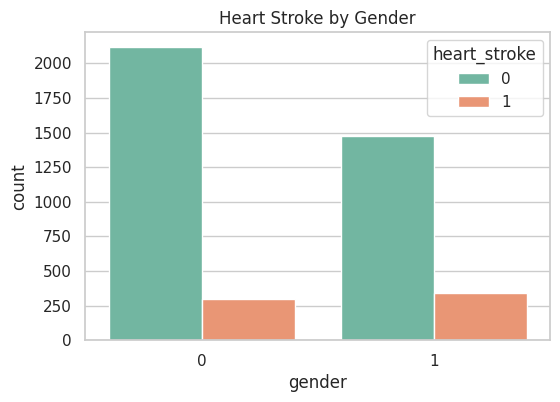

In [ ]:
# 4. Gender and Stroke
plt.figure(figsize = (6, 4))
sns.countplot(x = 'gender', hue = 'heart_stroke', data = df, palette = 'Set2')
plt.title('Heart Stroke by Gender')
plt.show()

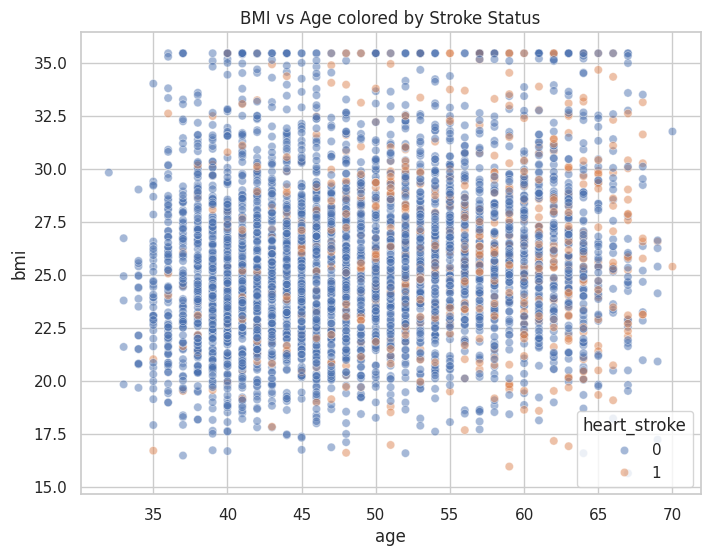

In [ ]:
# 5. BMI vs Age with Stroke status
plt.figure(figsize = (8, 6))
sns.scatterplot(x = 'age', y = 'bmi', hue = 'heart_stroke', data = df, alpha = 0.5)
plt.title('BMI vs Age colored by Stroke Status')
plt.show()

/tmp/ipykernel_1437/365675238.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'heart_stroke', y = 'age', data = df, palette = 'magma')


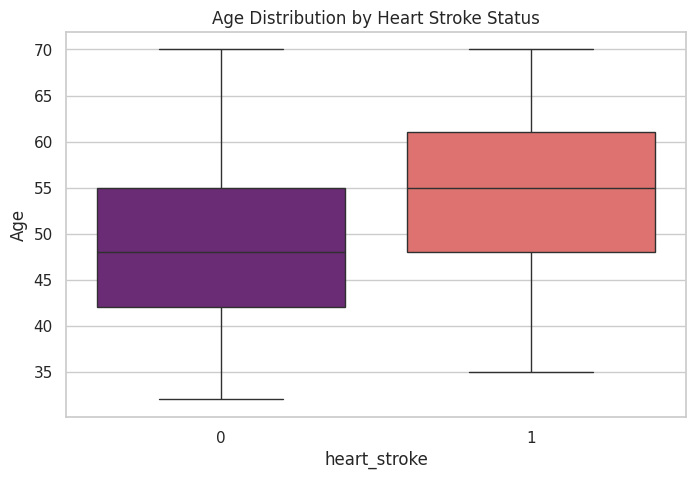

In [ ]:
# 6. Age vs. Stroke Risk
plt.figure(figsize = (8, 5))
sns.boxplot(x = 'heart_stroke', y = 'age', data = df, palette = 'magma')
plt.title('Age Distribution by Heart Stroke Status')
plt.ylabel('Age')
plt.show()

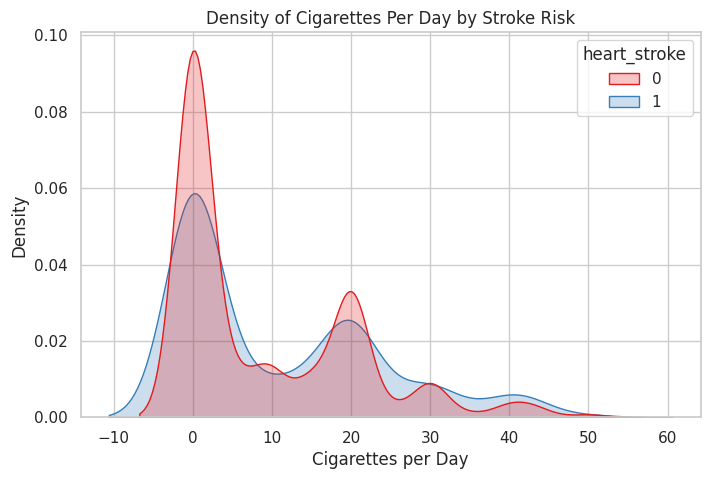

In [ ]:
# 7. Smoking Habits Density
plt.figure(figsize = (8, 5))
sns.kdeplot(data = df, x = 'cigsperday', hue = 'heart_stroke', fill = True, common_norm = False, palette = 'Set1')
plt.title('Density of Cigarettes Per Day by Stroke Risk')
plt.xlabel('Cigarettes per Day')
plt.show()

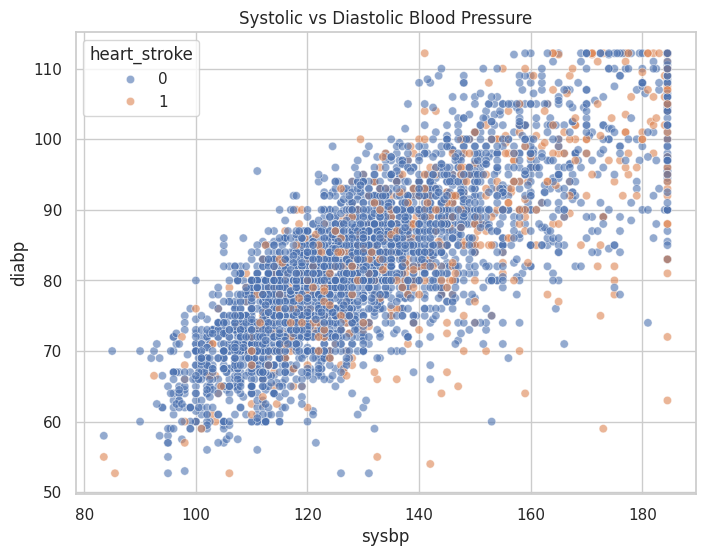

In [ ]:
# 8. Blood Pressure Relationships
plt.figure(figsize = (8, 6))
sns.scatterplot(x = 'sysbp', y = 'diabp', hue = 'heart_stroke', data = df, alpha = 0.6)
plt.title('Systolic vs Diastolic Blood Pressure')
plt.show()

<Figure size 1000x500 with 0 Axes>

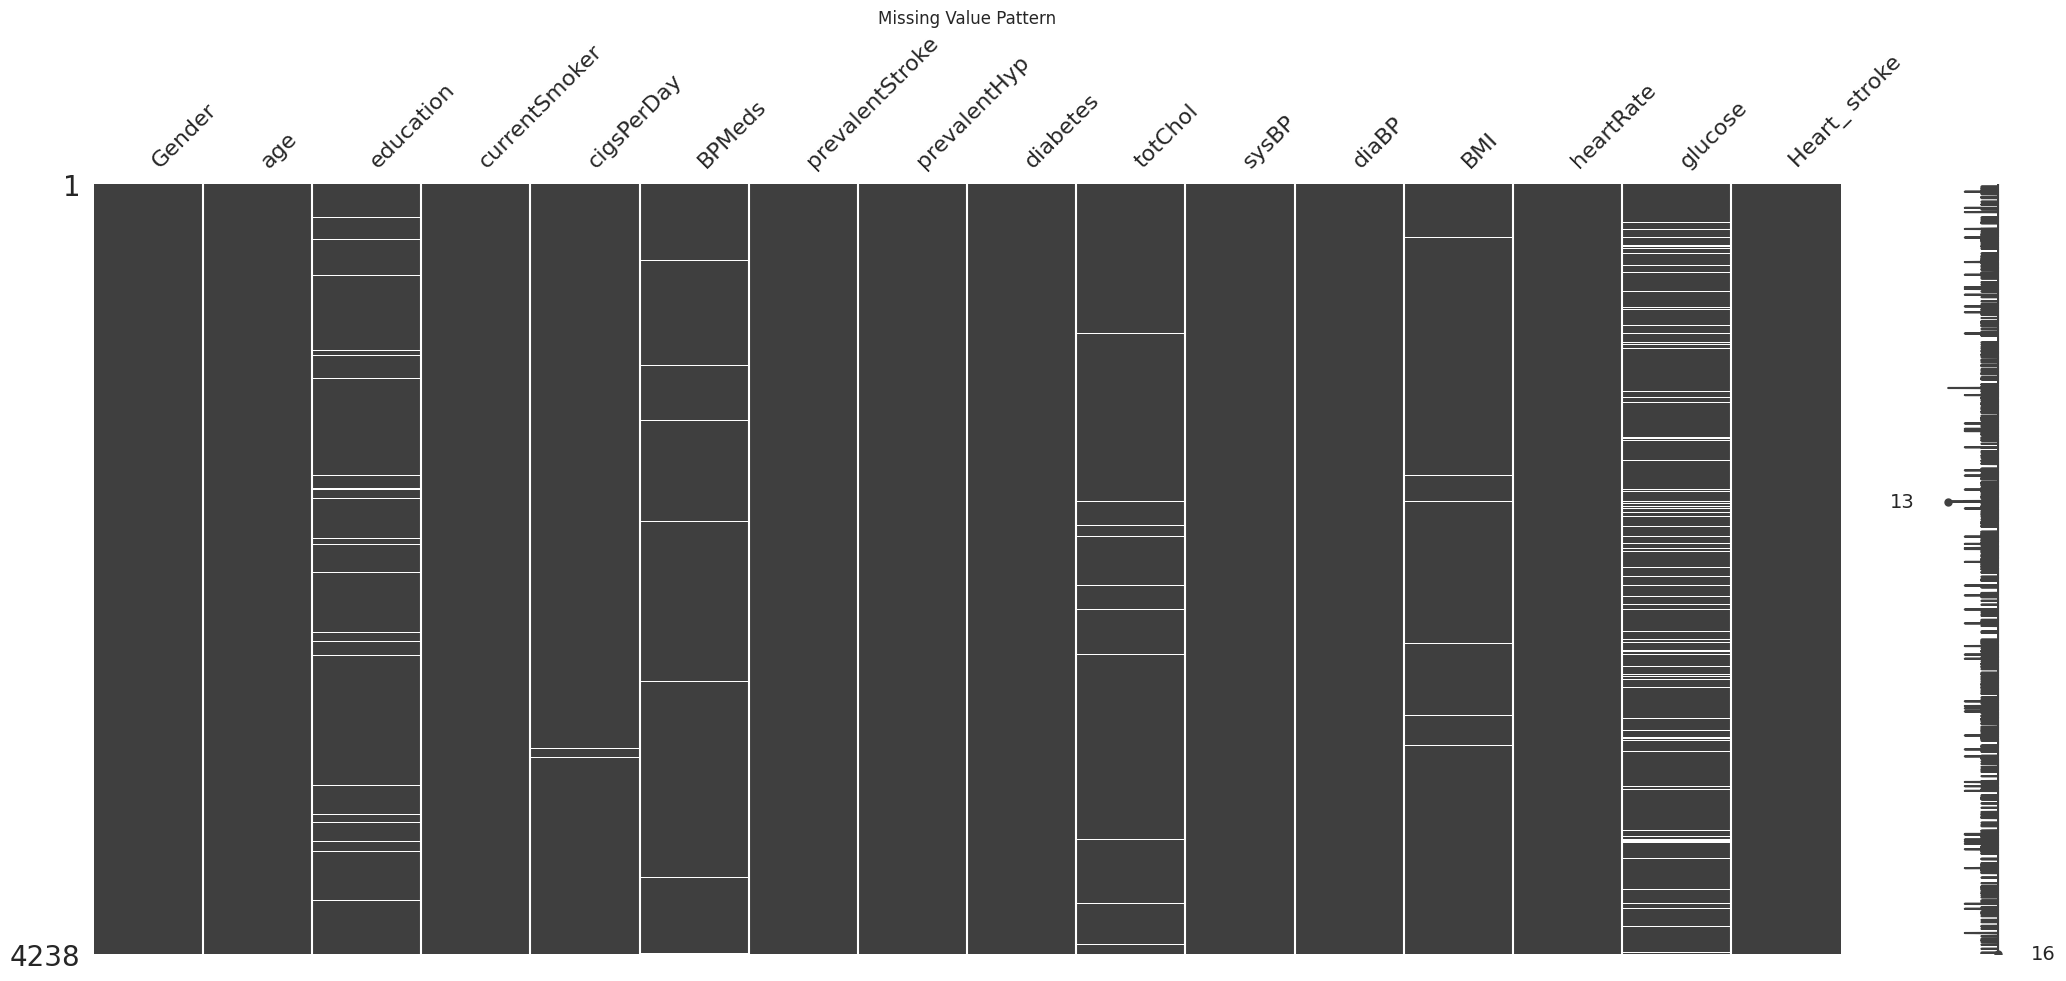

In [ ]:
import missingno as msno
import pandas as pd

# Load the original raw file
df_raw = pd.read_csv('heart_disease.csv')
plt.figure(figsize = (10,5))
msno.matrix(df_raw)
plt.title("Missing Value Pattern")
plt.show()

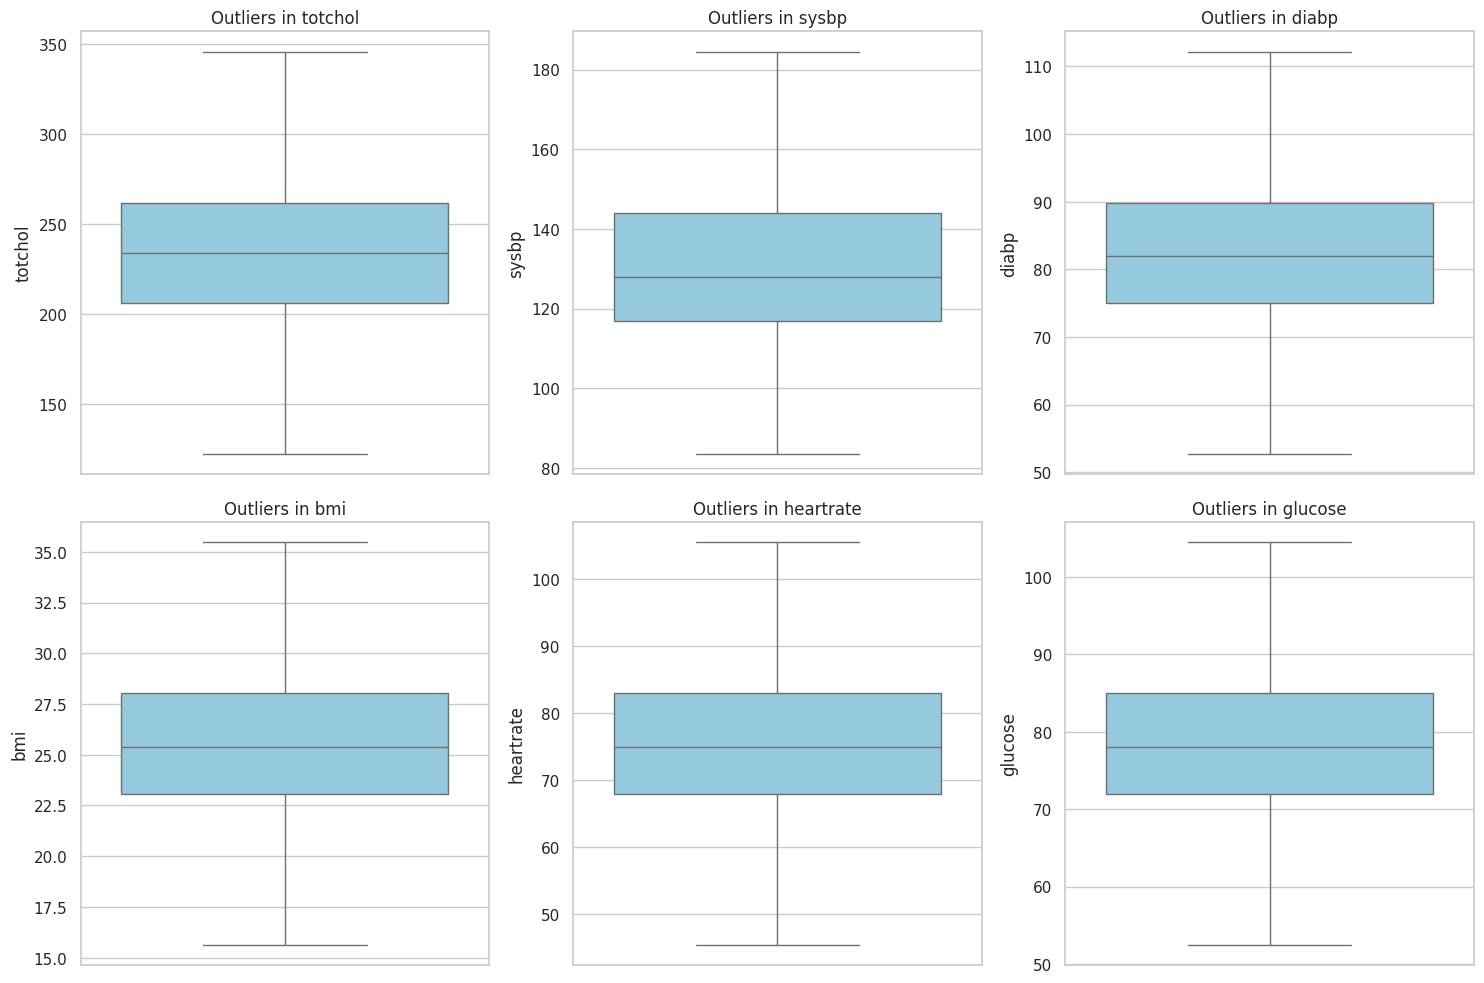

In [ ]:
# Boxplots for all numerical features to find outliers
cols_to_check = ['totchol', 'sysbp', 'diabp', 'bmi', 'heartrate', 'glucose']
plt.figure(figsize = (15, 10))
for i, col in enumerate(cols_to_check, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y = df[col], color = 'skyblue')
    plt.title(f'Outliers in {col}')
plt.tight_layout()
plt.show()

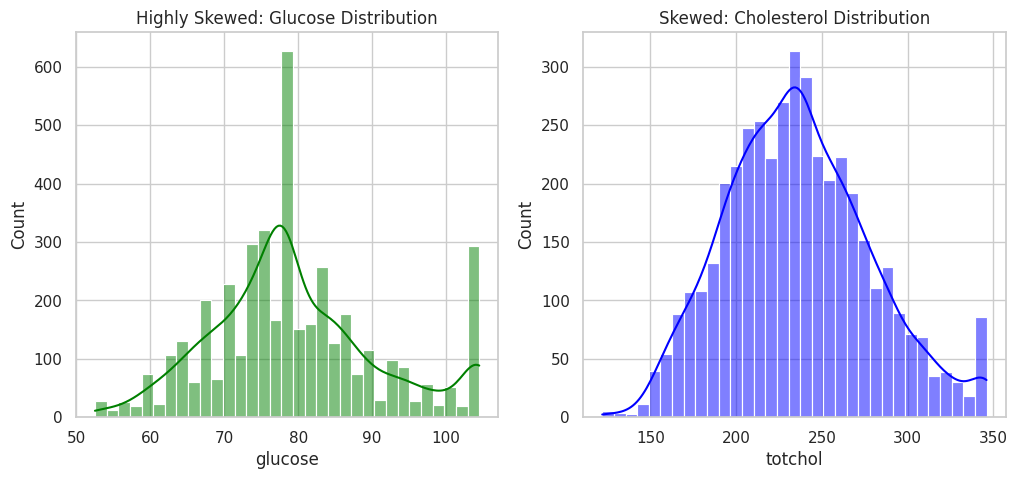

In [ ]:
# Checking distribution of skewed features
plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['glucose'], kde = True, color = 'green')
plt.title('Highly Skewed: Glucose Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['totchol'], kde = True, color = 'blue')
plt.title('Skewed: Cholesterol Distribution')
plt.show()

In [ ]:
# ===============================
# 4. MACHINE LEARNING EXPERIMENTS
# ===============================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Target column
target_col = 'heart_stroke'

# Remove missing target values
df = df.dropna(subset=[target_col])

# Features and target
X = df.drop(target_col, axis=1)
y = df[target_col].astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Preprocessing for numeric data
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# ===============================
# Model 1: Logistic Regression
# ===============================

log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

log_acc = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred, zero_division=0)
log_recall = recall_score(y_test, log_pred, zero_division=0)
log_f1 = f1_score(y_test, log_pred, zero_division=0)

print("Logistic Regression")
print("Accuracy:", log_acc)
print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1-score:", log_f1)
print(classification_report(y_test, log_pred, zero_division=0))

# ===============================
# Model 2: Decision Tree
# ===============================

dt_pipeline = Pipeline([
    ('preprocessor', SimpleImputer(strategy='median')),
    ('model', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

dt_params = {
    'model__max_depth': [3, 5, 7, 10],
    'model__min_samples_split': [2, 5, 10]
}

dt_grid = GridSearchCV(
    dt_pipeline,
    dt_params,
    cv=5,
    scoring='f1'
)

dt_grid.fit(X_train, y_train)
dt_pred = dt_grid.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred, zero_division=0)
dt_recall = recall_score(y_test, dt_pred, zero_division=0)
dt_f1 = f1_score(y_test, dt_pred, zero_division=0)

print("\nDecision Tree")
print("Best parameters:", dt_grid.best_params_)
print("Accuracy:", dt_acc)
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print("F1-score:", dt_f1)
print(classification_report(y_test, dt_pred, zero_division=0))

# ===============================
# Model 3: Random Forest
# ===============================

rf_pipeline = Pipeline([
    ('preprocessor', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

rf_params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring='f1'
)

rf_grid.fit(X_train, y_train)
rf_pred = rf_grid.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)

print("\nRandom Forest")
print("Best parameters:", rf_grid.best_params_)
print("Accuracy:", rf_acc)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1-score:", rf_f1)
print(classification_report(y_test, rf_pred, zero_division=0))

# ===============================
# Model Comparison
# ===============================

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [log_acc, dt_acc, rf_acc],
    'Precision': [log_precision, dt_precision, rf_precision],
    'Recall': [log_recall, dt_recall, rf_recall],
    'F1-score': [log_f1, dt_f1, rf_f1]
})

results = results.sort_values(by='F1-score', ascending=False)
print("\nModel Comparison:")
print(results)

# ===============================
# Final Model Selection
# ===============================

best_model_name = results.iloc[0]['Model']
print("\nBest model:", best_model_name)

if best_model_name == 'Logistic Regression':
    final_pred = log_pred
elif best_model_name == 'Decision Tree':
    final_pred = dt_pred
else:
    final_pred = rf_pred

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_pred))

print("\nFinal Conclusion:")
print(f"The best model for disease prediction is {best_model_name}.")
print("It was selected based on the highest F1-score.")

Logistic Regression
Accuracy: 0.6650943396226415
Precision: 0.24422442244224424
Recall: 0.5736434108527132
F1-score: 0.3425925925925926
              precision    recall  f1-score   support

           0       0.90      0.68      0.78       719
           1       0.24      0.57      0.34       129

    accuracy                           0.67       848
   macro avg       0.57      0.63      0.56       848
weighted avg       0.80      0.67      0.71       848


Decision Tree
Best parameters: {'model__max_depth': 5, 'model__min_samples_split': 2}
Accuracy: 0.6096698113207547
Precision: 0.2063953488372093
Recall: 0.5503875968992248
F1-score: 0.30021141649048627
              precision    recall  f1-score   support

           0       0.88      0.62      0.73       719
           1       0.21      0.55      0.30       129

    accuracy                           0.61       848
   macro avg       0.55      0.59      0.51       848
weighted avg       0.78      0.61      0.66       848


Random

## 5. Error Analysis & Limitations

### Model Performance Summary

| Model               | Accuracy | Precision | Recall | F1-Score |
|---------------------|----------|-----------|--------|----------|
| Logistic Regression | 0.665    | 0.244     | 0.574  | 0.343    |
| Random Forest       | 0.671    | 0.232     | 0.504  | 0.318    |
| Decision Tree       | 0.610    | 0.206     | 0.550  | 0.300    |

**Selected Model: Logistic Regression** (highest F1-score: 0.343)

---

### Confusion Matrix Analysis (Logistic Regression)

|                     | Predicted: No Stroke | Predicted: Stroke |
|---------------------|----------------------|-------------------|
| **Actual: No Stroke** | 490 (True Negative)  | 229 (False Positive) |
| **Actual: Stroke**    | 55 (False Negative)  | 74 (True Positive)   |

- The model correctly identified **74 out of 129 stroke cases** (57.4% recall)
- However, it also produced **229 false alarms** — patients flagged as high-risk who did not have a stroke
- More critically, **55 actual stroke cases were missed** (false negatives), which in a real medical context could be dangerous

---

### Key Limitations

**1. Severe Class Imbalance**
The dataset is heavily imbalanced: 719 non-stroke cases vs. only 129 stroke cases (~85% / 15% split).
This is why all three models achieve decent overall accuracy (~61–67%) but struggle with low precision on the minority class (stroke = 1).
Despite using `class_weight='balanced'`, precision for stroke prediction remains low (0.21–0.24).

**2. Low Precision on Stroke Class**
A precision of ~0.24 means that roughly **3 out of 4 stroke predictions are false positives**.
In a clinical setting, this could lead to unnecessary anxiety or over-treatment for patients.

**3. All Models Perform Similarly**
The narrow gap between all three models (F1: 0.30–0.34) suggests the bottleneck is the data itself — not the choice of algorithm. More data, especially more stroke cases, would likely improve all models significantly.

**4. Dataset Size**
The dataset contains 848 test samples, which is relatively small for a medical prediction task. A larger and more diverse dataset would improve generalization.

**5. Missing Features**
Clinically important factors such as family history of heart disease, cholesterol medication history, and stress levels are absent from the dataset, which may limit predictive power.

---

### Conclusion

Given the medical nature of this problem, **recall is more important than precision** — it is better to over-predict stroke risk (and follow up with further tests) than to miss a real case. Logistic Regression was selected as the final model because it achieves the best balance of recall (0.574) and F1-score (0.343) among the three models tested.

In [ ]:
import joblib
joblib.dump(rf_grid, 'final_model.pkl')
print("Model saved!")

Model saved!


In [ ]:
import ipywidgets as widgets
from IPython.display import display
import joblib
import numpy as np
import pandas as pd

model = joblib.load('final_model.pkl')

age        = widgets.IntSlider(value = 50, min = 20, max = 90, description = 'Age:')
gender     = widgets.Dropdown(options = [('Female', 0), ('Male', 1)], description = 'Gender:')
smoker     = widgets.Dropdown(options = [('No', 0), ('Yes', 1)], description = 'Smoker:')
cigs       = widgets.IntSlider(value = 0, min = 0, max = 60, description = 'Cigs/day:')
bpmeds     = widgets.Dropdown(options = [('No', 0), ('Yes', 1)], description = 'BP Meds:')
stroke     = widgets.Dropdown(options = [('No', 0), ('Yes', 1)], description = 'Prev Stroke:')
diabetes   = widgets.Dropdown(options = [('No', 0), ('Yes', 1)], description = 'Diabetes:')
totchol    = widgets.IntSlider(value = 200, min = 100, max = 400, description = 'Cholesterol:')
sysbp      = widgets.IntSlider(value = 120, min = 80, max = 200, description = 'Sys BP:')
diabp      = widgets.IntSlider(value = 80, min = 50, max = 130, description = 'Dia BP:')
bmi        = widgets.FloatSlider(value = 25.0, min = 10.0, max = 50.0, description = 'BMI:')
heartrate  = widgets.IntSlider(value = 75, min = 40, max = 150, description = 'Heart Rate:')
glucose    = widgets.IntSlider(value = 80, min = 40, max = 400, description = 'Glucose:')
education  = widgets.Dropdown(options = [('Uneducated',0),('Primary',1),('Graduate',2),('Postgraduate',3)], description = 'Education:')

output = widgets.Output()
button = widgets.Button(description = 'Predict', button_style = 'success')

def predict(b):
    output.clear_output()
    pulse_pressure = sysbp.value - diabp.value
    heavy_smoker   = 1 if cigs.value > 20 else 0
    age_group      = pd.cut([age.value], bins = [0,40,50,60,100], labels = [0,1,2,3])[0]

    data = pd.DataFrame([
        {
            'gender': gender.value, 'age': age.value, 'education': education.value,
            'currentsmoker': smoker.value, 'cigsperday': cigs.value,
            'bpmeds': bpmeds.value, 'prevalentstroke': stroke.value,
            'prevalenthyp': 0, # Added missing feature with default value 0
            'diabetes': diabetes.value, 'totchol': totchol.value,
            'sysbp': sysbp.value, 'diabp': diabp.value, 'bmi': bmi.value,
            'heartrate': heartrate.value, 'glucose': glucose.value,
            'pulse_pressure': pulse_pressure, 'heavy_smoker': heavy_smoker,
            'age_group': age_group
        }
    ])

    pred = model.predict(data)[0]
    prob = model.predict_proba(data)[0][1]

    with output:
        if pred == 1:
            print(f" HIGH RISK of heart stroke  (probability: {prob:.1%})")
        else:
            print(f" LOW RISK of heart stroke  (probability: {prob:.1%})")

button.on_click(predict)
display(age, gender, education, smoker, cigs, bpmeds, stroke, diabetes,
        totchol, sysbp, diabp, bmi, heartrate, glucose, button, output)

IntSlider(value=50, description='Age:', max=90, min=20)

Dropdown(description='Gender:', options=(('Female', 0), ('Male', 1)), value=0)

Dropdown(description='Education:', options=(('Uneducated', 0), ('Primary', 1), ('Graduate', 2), ('Postgraduate…

Dropdown(description='Smoker:', options=(('No', 0), ('Yes', 1)), value=0)

IntSlider(value=0, description='Cigs/day:', max=60)

...

FloatSlider(value=25.0, description='BMI:', max=50.0, min=10.0)

IntSlider(value=75, description='Heart Rate:', max=150, min=40)

IntSlider(value=80, description='Glucose:', max=400, min=40)

Button(button_style='success', description='Predict', style=ButtonStyle())

Output()